# 📊 Notebook 02 — Data Pipeline
**Download → Clean → Feature Engineer → Normalise → Sequence → Save**


In [20]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import yfinance as yf
# import pandas_ta as pta  # DISABLED
from sklearn.preprocessing import MinMaxScaler
import yaml, pickle, os
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

BASE_DIR = Path('.')
DATA_RAW  = BASE_DIR / 'data' / 'raw'
DATA_PROC = BASE_DIR / 'data' / 'processed'
DATA_RAW.mkdir(parents=True, exist_ok=True)
DATA_PROC.mkdir(parents=True, exist_ok=True)

with open(BASE_DIR / 'configs' / 'data_config.yaml') as f:
    cfg = yaml.safe_load(f)

SYMBOLS     = cfg['symbols']['equities'] + cfg['symbols']['crypto']
TRAIN_START = cfg['train_start']
TEST_END    = cfg['test_end']
INTERVAL    = cfg['interval']
SEQ_LEN     = 60

print(f'📦 Symbols: {SYMBOLS}')
print(f'📅 Period: {TRAIN_START} → {TEST_END}')

📦 Symbols: ['AAPL', 'MSFT', 'GOOGL', 'SPY', 'QQQ', 'TSLA', 'BTC-USD', 'ETH-USD']
📅 Period: 2012-01-01 → 2026-05-31


## 1. Download OHLCV Data

In [21]:
def download_data(symbol: str, start: str, end: str, interval: str = '1d') -> pd.DataFrame:
    """Download OHLCV from Yahoo Finance with retry logic."""
    try:
        df = yf.download(symbol, start=start, end=end, interval=interval,
                         auto_adjust=True, progress=False, multi_level_index=False)
        df.columns = [c[0].lower() if isinstance(c, tuple) else c.lower() for c in df.columns]
        df.dropna(inplace=True)
        df.index = pd.to_datetime(df.index)
        print(f'  ✅ {symbol}: {len(df)} bars ({df.index[0].date()} → {df.index[-1].date()})')
        return df
    except Exception as e:
        print(f'  ❌ {symbol}: {e}')
        return pd.DataFrame()

raw_data = {}
print('⬇️  Downloading data...')
for sym in tqdm(SYMBOLS):
    df = download_data(sym, TRAIN_START, TEST_END, INTERVAL)
    if not df.empty:
        raw_data[sym] = df
        df.to_csv(DATA_RAW / f'{sym.replace("-","_")}.csv')

print(f'\n✅ Downloaded {len(raw_data)} symbols.')

⬇️  Downloading data...


  0%|                                                              | 0/8 [00:00<?, ?it/s]

  ✅ AAPL: 3622 bars (2012-01-03 → 2026-05-29)


 38%|████████████████████▎                                 | 3/8 [00:00<00:00,  9.01it/s]

  ✅ MSFT: 3622 bars (2012-01-03 → 2026-05-29)
  ✅ GOOGL: 3622 bars (2012-01-03 → 2026-05-29)
  ✅ SPY: 3622 bars (2012-01-03 → 2026-05-29)


...

  ✅ QQQ: 3622 bars (2012-01-03 → 2026-05-29)
  ✅ TSLA: 3622 bars (2012-01-03 → 2026-05-29)


 88%|███████████████████████████████████████████████▎      | 7/8 [00:00<00:00, 11.13it/s]

  ✅ BTC-USD: 4274 bars (2014-09-17 → 2026-05-30)


100%|██████████████████████████████████████████████████████| 8/8 [00:00<00:00, 10.65it/s]

  ✅ ETH-USD: 3125 bars (2017-11-09 → 2026-05-30)

✅ Downloaded 8 symbols.


## 2. Feature Engineering

In [22]:
import ta

def add_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add comprehensive technical indicators using the `ta` library."""
    df = df.copy()

    # ---- Momentum ----
    df['rsi_14']      = ta.momentum.RSIIndicator(df['close'], window=14).rsi()
    df['rsi_7']       = ta.momentum.RSIIndicator(df['close'], window=7).rsi()
    _macd             = ta.trend.MACD(df['close'], window_slow=26, window_fast=12, window_sign=9)
    df['macd']        = _macd.macd()
    df['macd_signal'] = _macd.macd_signal()
    df['macd_hist']   = _macd.macd_diff()
    _stoch            = ta.momentum.StochasticOscillator(df['high'], df['low'], df['close'], window=14)
    df['stoch_k']     = _stoch.stoch()
    df['stoch_d']     = _stoch.stoch_signal()
    df['williams_r']  = ta.momentum.WilliamsRIndicator(df['high'], df['low'], df['close'], lbp=14).williams_r()

    # ---- Trend ----
    df['ema_9']       = ta.trend.EMAIndicator(df['close'], window=9).ema_indicator()
    df['ema_21']      = ta.trend.EMAIndicator(df['close'], window=21).ema_indicator()
    df['ema_50']      = ta.trend.EMAIndicator(df['close'], window=50).ema_indicator()
    df['ema_200']     = ta.trend.EMAIndicator(df['close'], window=200).ema_indicator()
    df['sma_20']      = ta.trend.SMAIndicator(df['close'], window=20).sma_indicator()
    df['adx']         = ta.trend.ADXIndicator(df['high'], df['low'], df['close'], window=14).adx()
    df['cci_20']      = ta.trend.CCIIndicator(df['high'], df['low'], df['close'], window=20).cci()

    # ---- Volatility ----
    _bb               = ta.volatility.BollingerBands(df['close'], window=20, window_dev=2)
    df['bb_upper']    = _bb.bollinger_hband()
    df['bb_middle']   = _bb.bollinger_mavg()
    df['bb_lower']    = _bb.bollinger_lband()
    df['bb_bw']       = (df['bb_upper'] - df['bb_lower']) / df['bb_middle']
    df['atr_14']      = ta.volatility.AverageTrueRange(df['high'], df['low'], df['close'], window=14).average_true_range()
    df['atr_7']       = ta.volatility.AverageTrueRange(df['high'], df['low'], df['close'], window=7).average_true_range()
    df['vol_20']      = df['close'].pct_change().rolling(20).std()
    df['vol_60']      = df['close'].pct_change().rolling(60).std()

    # ---- Volume ----
    df['obv']         = ta.volume.OnBalanceVolumeIndicator(df['close'], df['volume']).on_balance_volume()
    df['mfi_14']      = ta.volume.MFIIndicator(df['high'], df['low'], df['close'], df['volume'], window=14).money_flow_index()
    df['vol_ratio']   = df['volume'] / df['volume'].rolling(20).mean()

    # ---- Derived ----
    df['log_return']    = np.log(df['close'] / df['close'].shift(1))
    df['hl_spread']     = (df['high'] - df['low']) / df['close']
    df['price_ema50_r'] = df['close'] / df['ema_50']

    df.dropna(inplace=True)
    return df

print('⚙️  Engineering features...')
featured_data = {}
for sym, df in tqdm(raw_data.items()):
    try:
        featured_data[sym] = add_features(df)
        print(f'  {sym}: {len(featured_data[sym])} clean bars, {featured_data[sym].shape[1]} features')
    except Exception as e:
        print(f'  ⚠️  {sym}: feature engineering failed — {e}')


⚙️  Engineering features...


 12%|██████▊                                               | 1/8 [00:00<00:01,  4.59it/s]

  AAPL: 3423 clean bars, 34 features


 38%|████████████████████▎                                 | 3/8 [00:00<00:01,  4.90it/s]

  MSFT: 3423 clean bars, 34 features
  GOOGL: 3423 clean bars, 34 features


...

  SPY: 3423 clean bars, 34 features
  QQQ: 3423 clean bars, 34 features


 75%|████████████████████████████████████████▌             | 6/8 [00:01<00:00,  4.70it/s]

  TSLA: 3423 clean bars, 34 features


100%|██████████████████████████████████████████████████████| 8/8 [00:01<00:00,  4.77it/s]

  BTC-USD: 4075 clean bars, 34 features
  ETH-USD: 2926 clean bars, 34 features


## 3. Generate Labels (Supervised LSTM Targets)

In [23]:
def generate_labels(df: pd.DataFrame, forward_bars: int = 5, threshold: float = 0.005) -> pd.DataFrame:
    """Generate 3-class labels based on forward N-bar return.
    0 = Hold, 1 = Buy (return > threshold), 2 = Sell (return < -threshold)
    """
    df = df.copy()
    forward_return = df['close'].shift(-forward_bars) / df['close'] - 1
    df['label'] = 0  # Hold default
    df.loc[forward_return >  threshold, 'label'] = 1  # Buy
    df.loc[forward_return < -threshold, 'label'] = 2  # Sell
    df.dropna(inplace=True)
    
    counts = df['label'].value_counts().sort_index()
    total = len(df)
    print(f'  Label distribution: Hold={counts.get(0,0)/total:.1%}  '
          f'Buy={counts.get(1,0)/total:.1%}  Sell={counts.get(2,0)/total:.1%}')
    return df

labelled_data = {}
for sym, df in featured_data.items():
    print(f'  {sym}:')
    labelled_data[sym] = generate_labels(df)

print('\n✅ Labels generated.')

  AAPL:
  Label distribution: Hold=12.0%  Buy=51.0%  Sell=36.9%
  MSFT:
  Label distribution: Hold=14.2%  Buy=51.3%  Sell=34.5%
  GOOGL:
  Label distribution: Hold=12.6%  Buy=51.2%  Sell=36.2%
  SPY:
  Label distribution: Hold=24.0%  Buy=48.8%  Sell=27.2%
  QQQ:
  Label distribution: Hold=16.8%  Buy=51.9%  Sell=31.3%
  TSLA:
  Label distribution: Hold=6.4%  Buy=51.1%  Sell=42.5%
  BTC-USD:
  Label distribution: Hold=9.1%  Buy=50.3%  Sell=40.6%
  ETH-USD:
  Label distribution: Hold=5.6%  Buy=49.2%  Sell=45.2%

✅ Labels generated.


## 4. Train / Val / Test Split + Normalisation

In [24]:
FEATURE_COLS = [
    'open','high','low','close','volume',
    'rsi_14','rsi_7','macd','macd_signal','macd_hist',
    'stoch_k','stoch_d','williams_r',
    'ema_9','ema_21','ema_50','sma_20','adx','cci_20',
    'bb_upper','bb_lower','bb_bw',
    'atr_14','atr_7','vol_20','vol_60',
    'obv','mfi_14','vol_ratio',
    'log_return','hl_spread','price_ema50_r'
]

TRAIN_CUTOFF = '2021-12-31'
VAL_CUTOFF   = '2020-12-31'   # val = 2021 only
TEST_START   = '2022-01-01'

def make_sequences(X: np.ndarray, y: np.ndarray, seq_len: int):
    """Create sliding window sequences from feature matrix."""
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.int64)

processed = {}

for sym, df in labelled_data.items():
    # ---- Filter available features ----
    avail_feats = [c for c in FEATURE_COLS if c in df.columns]
    
    # ---- Time-aware split ----
    df_train = df[df.index <= TRAIN_CUTOFF]
    df_val   = df[(df.index > VAL_CUTOFF) & (df.index <= TRAIN_CUTOFF)]
    df_test  = df[df.index >= TEST_START]
    
    # ---- Fit scaler on TRAIN only ----
    scaler = MinMaxScaler(feature_range=(-1, 1))
    scaler.fit(df_train[avail_feats])
    
    X_train = scaler.transform(df_train[avail_feats])
    X_val   = scaler.transform(df_val[avail_feats])
    X_test  = scaler.transform(df_test[avail_feats])
    
    y_train = df_train['label'].values
    y_val   = df_val['label'].values
    y_test  = df_test['label'].values
    
    # ---- Sequences ----
    X_tr_seq, y_tr_seq = make_sequences(X_train, y_train, SEQ_LEN)
    X_va_seq, y_va_seq = make_sequences(X_val, y_val, SEQ_LEN)
    X_te_seq, y_te_seq = make_sequences(X_test, y_test, SEQ_LEN)
    
    processed[sym] = {
        'X_train': X_tr_seq, 'y_train': y_tr_seq,
        'X_val':   X_va_seq, 'y_val':   y_va_seq,
        'X_test':  X_te_seq, 'y_test':  y_te_seq,
        'scaler':  scaler,
        'features': avail_feats,
        'test_prices': df_test[['open','high','low','close','volume']],
    }
    
    print(f'  {sym}: Train={X_tr_seq.shape}, Val={X_va_seq.shape}, Test={X_te_seq.shape}')
    
    # ---- Save ----
    with open(DATA_PROC / f'{sym.replace("-","_")}_processed.pkl', 'wb') as f:
        pickle.dump(processed[sym], f)

print('\n✅ All processed datasets saved to data/processed/')

  AAPL: Train=(2258, 60, 32), Val=(192, 60, 32), Test=(1045, 60, 32)
  MSFT: Train=(2258, 60, 32), Val=(192, 60, 32), Test=(1045, 60, 32)
  GOOGL: Train=(2258, 60, 32), Val=(192, 60, 32), Test=(1045, 60, 32)
  SPY: Train=(2258, 60, 32), Val=(192, 60, 32), Test=(1045, 60, 32)
  QQQ: Train=(2258, 60, 32), Val=(192, 60, 32), Test=(1045, 60, 32)
  TSLA: Train=(2258, 60, 32), Val=(192, 60, 32), Test=(1045, 60, 32)
  BTC-USD: Train=(2404, 60, 32), Val=(305, 60, 32), Test=(1551, 60, 32)
  ETH-USD: Train=(1255, 60, 32), Val=(305, 60, 32), Test=(1551, 60, 32)

✅ All processed datasets saved to data/processed/


## 5. Visualise Sample

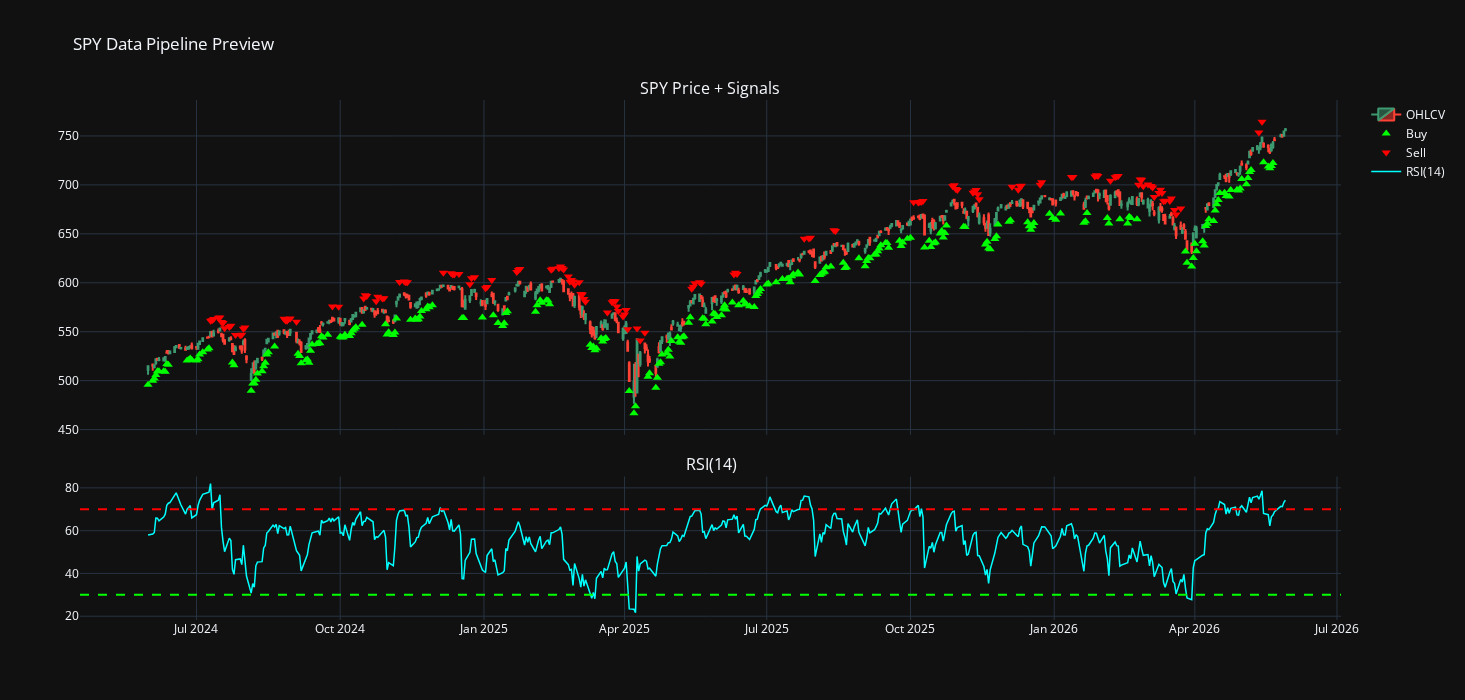

In [25]:
# Plot SPY price with buy/sell labels
sym = 'SPY'
if sym in labelled_data:
    df_plot = labelled_data[sym].iloc[-500:]  # Last 500 bars
    
    fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                        subplot_titles=['SPY Price + Signals', 'RSI(14)'],
                        vertical_spacing=0.08, row_heights=[0.7, 0.3])
    
    fig.add_trace(go.Candlestick(x=df_plot.index, open=df_plot['open'], high=df_plot['high'],
                                  low=df_plot['low'], close=df_plot['close'], name='OHLCV'), row=1, col=1)
    
    buys  = df_plot[df_plot['label'] == 1]
    sells = df_plot[df_plot['label'] == 2]
    fig.add_trace(go.Scatter(x=buys.index, y=buys['low']*0.98, mode='markers',
                              marker=dict(symbol='triangle-up', size=8, color='lime'), name='Buy'), row=1, col=1)
    fig.add_trace(go.Scatter(x=sells.index, y=sells['high']*1.02, mode='markers',
                              marker=dict(symbol='triangle-down', size=8, color='red'), name='Sell'), row=1, col=1)
    fig.add_trace(go.Scatter(x=df_plot.index, y=df_plot['rsi_14'], line=dict(color='cyan', width=1.5),
                              name='RSI(14)'), row=2, col=1)
    fig.add_hline(y=70, line_dash='dash', line_color='red', row=2, col=1)
    fig.add_hline(y=30, line_dash='dash', line_color='lime', row=2, col=1)

    fig.update_layout(height=700, template='plotly_dark', title='SPY Data Pipeline Preview',
                      showlegend=True, xaxis_rangeslider_visible=False)
    fig.show()
else:
    print('SPY not in downloaded symbols — plotting first available symbol')
    if not labelled_data:
        print('⚠️  labelled_data is empty — re-run cells 1→3 first.')
    else:
        sym = list(labelled_data.keys())[0]
    print(f'Showing: {sym}')